# <font color="#084B8A"> Taller de herramientas computacionales </font>
## Python - Notas de clase  
***Facultad de Ciencias, UNAM***  
*Semestre 2024-2*  
Jorge Zavaleta Sánchez

# Aplicaciones
## Gráficas de funciones

En python es posible realizar gráficas de funciones reales ($f:[a,b]\subset \mathbb{R}\to \mathbb{R}$) y funciones escalares ($f:[a,b]\times[c,d]\subset \mathbb{R}^{2}\to \mathbb{R}$), entre otras. Para este fin se usará el módulo `matplolib`, en particular `pyplot` para realizar gráficas en 2D y `mplot3D` para gráficas en 3D. Las funciones y forma de usar son similares a las funciones que se ocupan en Matlab/Octave.

Lo primero que se necesita es cargar todos los módulos necesarios para poder crear las gráficas.

In [ ]:
# Se cargan las librerias y paquetes
import numpy as np
from matplotlib import pyplot as plt  # Graficas 2D
from mpl_toolkits.mplot3d import Axes3D  # Graficas 3D
%matplotlib inline

Aunque `matplotlib` fue inicialmente concebida para crear gráficos en 2D, después se extendió su uso para gráficas en 3D. La instrucción `%matplolib` es lo que se conoce como una *función mágica* dentro del shell interactivo *IPython* que usa Jupyter. Esto permite tener un modo interactivo con las gráficas si se cambia `inline` por `notebook`. Si se omite, en las libretas queda en forma `inline`. Información adicional puede ser encontrada en la siguiente [liga](https://stackoverflow.com/questions/43027980/purpose-of-matplotlib-inline).

**Nota**: La instrucción `%matplolib` no trabaja en Colab, en un ejemplo veremos como activar el modo interactivo de las gráficas.

### Gráficas 2D

Para crear gráficas en 2D debemos usar la función `plot` que se encuentra en `pyplot`. En este caso la sintaxis básica es la siguiente:
```python
plt.plot(x, y, [fmt])
```
donde `x` son las abscisas, `y` son las ordenadas y `fmt` (opcional) corresponde a una cadena que define el formato básico para la apariencia de las líneas. La documentación completa de la función `plot` puede ser consultada en la siguiente [liga](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html).

Para mostrar su uso considérese los siguientes ejemplos.

Dame el numero de puntos a graficar: 60


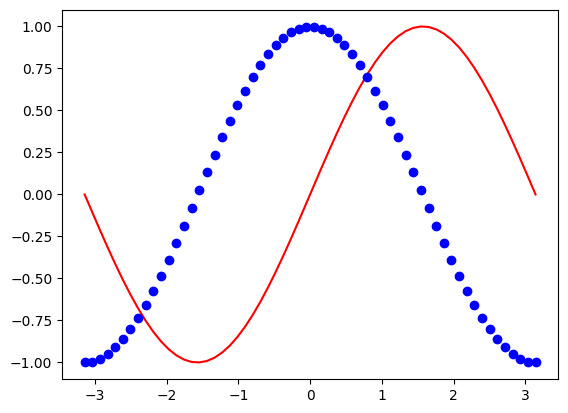

In [ ]:
puntos = int(input('Dame el numero de puntos a graficar: '))
x = np.linspace(-np.pi, np.pi, puntos)
y, z = np.sin(x), np.cos(x)
plt.plot(x, y, '-r')
plt.plot(x, z, 'ob')
plt.show()

En este caso se usan funciones que se encuentran dentro del módulo `numpy` para generar el conjunto de coordenadas donde se evalúa la función. En particular, se usa `linspace` para crear las abscisas y después se evalúan estas en una función para obtener las ordenadas que definirán el par ordenado que se gráfica mediante `plot`. Es importante poner la instrucción `plt.show()` para mostrar la gráfica.

Se pueden graficar varias curvas en una misma figura al ejecutar la instrucción `plot` con diferentes conjuntos de pares ordenados, como en el ejemplo anterior. También se pueden dar modificaciones en el aspecto de las curvas, como son el color, grosor, marcadores. etc. Todo esto puede ser consultado en la [documentación](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

En los ejemplos se usarán los arreglos (`ndarray`) de `numpy` debido a las funcionalidades que estos proveen, pero es posible utilizar otros tipos de datos, como listas o tuplas, para mandar las coordenadas a la función `plot`. Por ejemplo, usando listas

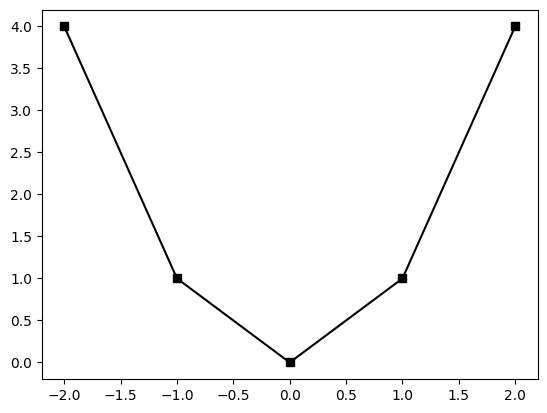

In [ ]:
u = [-2, -1, 0, 1, 2]
v = list(map(lambda x: x**2, u))
plt.plot(u, v, 'sk-')
plt.show()

También es posible crear etiquetas para los ejes, leyendas y títulos que soportan comandos en *LaTeX*. Estás son propiedades que pertenecen a los ejes, por lo cual es necesario obtener el control sobre los ejes actuales mediante la función `gca()`. Esto se muestra en el siguiente ejemplo

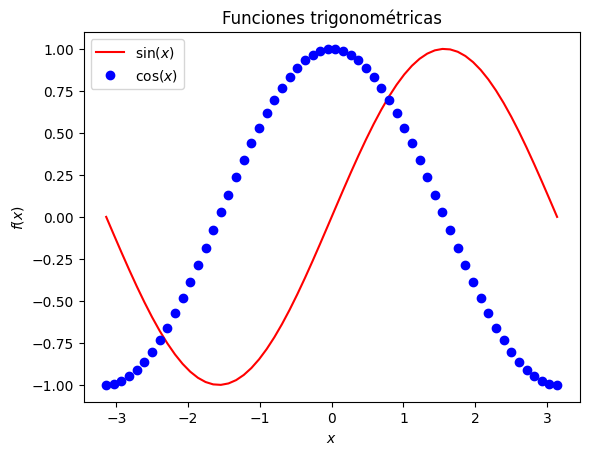

In [ ]:
x = np.linspace(-np.pi, np.pi, puntos)
y, z = np.sin(x), np.cos(x)
plt.plot(x, y, '-r', label='$\sin(x)$')
plt.plot(x, z, 'ob', label='$\cos(x)$')
ax = plt.gca()  # Se obtiene el control para los ejes actuales
ax.set_xlabel('$x$')  # Etiqueta eje x
ax.set_ylabel('$f(x)$')  # Etiqueta eje y
ax.set_title('Funciones trigonométricas')  # Titulo
ax.legend(loc = 'upper left')  # Leyenda a partir de las etiquetas
plt.savefig('Fig.pdf')  # Guardamos la figura en el archivo Fig.pdf

**Nota**: Es posible guardar la imagen en un archivo mediante la función `savefig`, la cual soporta diferentes tipos de archivos, incluyendo los más comunes como `.pdf`, `.png`, `.jpg`, `.eps`, etc. Cuando se guarda a un archivo, hay que omitir la instrucción `plt.show()`, para que la gráfica se imprima al archivo y no al visualizador de la libreta.

Es posible generar graficas donde solo aparecen puntos dispersos sin lineas mediante la función `scatter`.

Dame el numero de puntos a graficar: 150


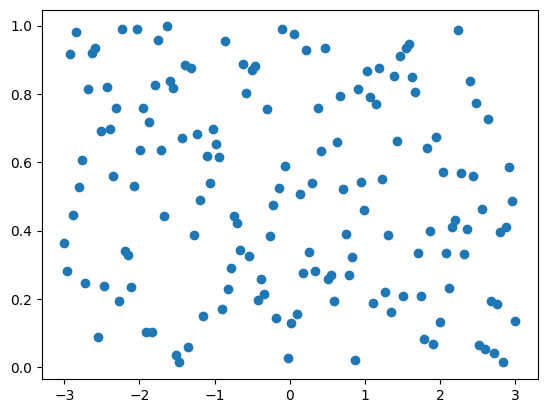

In [ ]:
puntos = int(input('Dame el numero de puntos a graficar: '))
x = np.linspace(-3, 3, puntos)
y = np.random.rand(puntos)
plt.scatter(x, y)
plt.show()

### Gráficas 3D

Para cambiar la perspectiva de los ejes a tres dimensiones se utiliza `Axes3D`, lo cual da el efecto de profundidad. Esto se hace a través de las siguientes tres instrucciones

```python
fig = plt.figure()
# En algunas versiones hay que poner auto_add_to_figure=False
ax = Axes3D(fig)  # ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
```

donde la primera instrucción crea una figura, la segunda crea los ejes con perspectiva en 3 dimensiones y la tercera agrega los ejes a la figura. Esto se hace así a partir de la versión 3.4.0 de `matplolib` pero cambiará en versiones posteriores (véase la siguiente [liga](https://matplotlib.org/3.5.1/api/prev_api_changes/api_changes_3.4.0.html) en el tema "*Axes3D automatically adding itself to Figure is deprecated*"). En versiones anteriores se puede hacer mediante

```python
fig = plt.figure()
ax = Axes3D(fig)
```

Para mostrar su uso, se hará un ejemplo con la curva paramétrica $$x = \sqrt{t}\sin(2t),$$ $$y = \sqrt{t}\cos(2t),$$ $$z = \frac{t}{2},$$ con $0\leq t\leq 6\pi$.

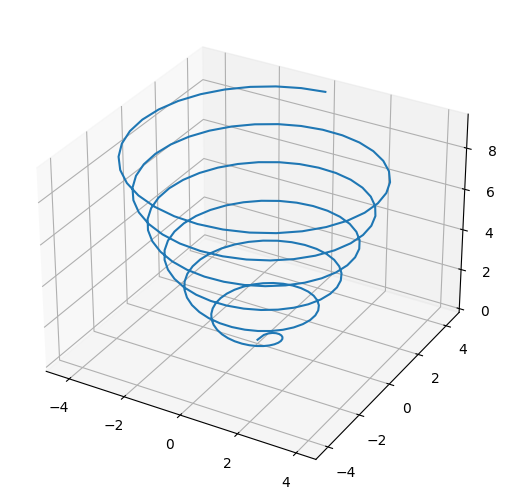

In [ ]:
# Ejemplo de curva paramétrica
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
t = np.linspace(0, 6*np.pi, 200)
x = np.sqrt(t)*np.sin(2*t)
y = np.sqrt(t)*np.cos(2*t)
z = 0.5*t
plt.plot(x, y, z)
plt.show()

La función `plot` en este caso hace la gráfica tomando en cuenta la profundidad y genera una figura en 3D. También es posible hacerlo usando la siguiente instrucción

```python
ax = plt.axes(projection='3d')
```

pero cargando el modulo `mplot3d` directamente

```python
from mpl_toolkits import mplot3d
```

Con esta forma, se cambia la perspectiva directamente desde los ejes a través de la opción `projection`, aunque esto ya se cambió en la versión actual de `matplotlib` por la usada en el ejemplo anterior, y ya no se recomienda. De todas maneras, el código para generar la misma figura con este procedimiento desde cero, quedaría de la siguiente manera:

```python
import numpy as np #Rutinas numericas
from matplotlib import pyplot as plt #Graficas 2D
from mpl_toolkits import mplot3d #Graficas 3D

ax = plt.axes(projection='3d')
t = np.linspace(0, 6*np.pi, 200)
x = np.sqrt(t)*np.sin(2*t)
y = np.sqrt(t)*np.cos(2*t)
z = 0.5*t
ax.plot(x, y, z)
plt.show()
```

la cual pueden probar en una libreta aparte o desde un archivo `.py`.

También se pueden generar superficies a partir de funciones escalares $f(x,y)\colon\mathbb{R}^2 \to \mathbb{R}$. Para ello se necesita de una malla para tener los puntos de evaluación y generar los pares ordenados en arreglos. En *Python*, para hacer esto (en *Matlab/Octave* es de forma análoga) se puede usar la función `meshgrid` de `numpy`. El código para generar la gráfica de la función $$f(x,y) = \cos(x)e^{\sin(y)}$$ como una superficie mediante la función `plot_surface` se da a continuación.

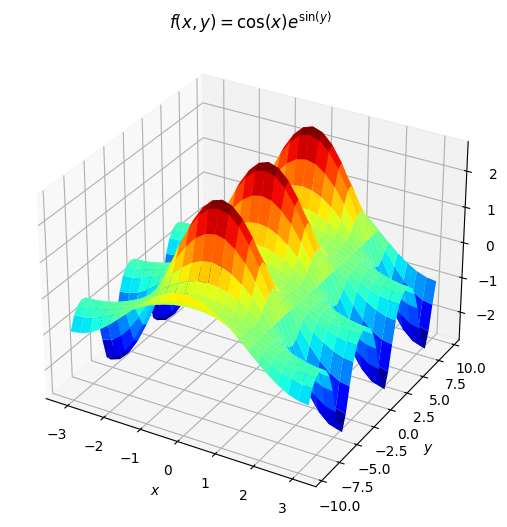

In [ ]:
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
x = np.linspace(-np.pi, np.pi, 25)
y = np.linspace(-3*np.pi, 3*np.pi, 40)
X, Y = np.meshgrid(x, y)
Z = np.cos(X)*np.exp(np.sin(Y))
ax.plot_surface(X, Y, Z, cmap='jet')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_title('$f(x,y) = \cos(x)e^{\sin(y)}$')
#plt.savefig('superficie.pdf')
plt.show()

El mapa de colores se cambia a través de la opción `cmap` y tienen nombres parecidos a los usados en *Matlab/Octave*. Puede consultar la siguiente [liga](https://claudiovz.github.io/scipy-lecture-notes-ES/intro/matplotlib/matplotlib.html#colormaps) para los mapas de colores disponibles o la [documentación](https://matplotlib.org/stable/tutorials/colors/colormaps.html) de `matplotlib`.

Se pueden generar gráficas sin los parches rellenos, es decir, mostrando solo la malla con el comando `plot_wireframe` donde los colores de las líneas se cambian a través de la opción `color` (valores disponibles en la siguiente [liga](https://matplotlib.org/stable/gallery/color/named_colors.html)).

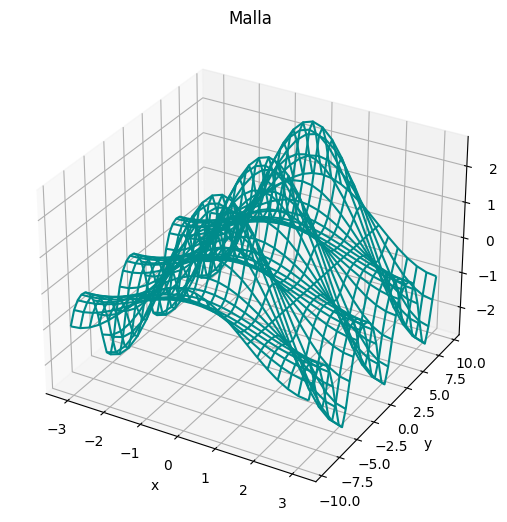

In [ ]:
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
x = np.linspace(-np.pi, np.pi, 25)
y = np.linspace(-3*np.pi, 3*np.pi, 40)
X, Y = np.meshgrid(x, y)
Z = np.cos(X)*np.exp(np.sin(Y))
ax.plot_wireframe(X, Y, Z, color='darkcyan')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Malla')
plt.savefig('Malla.pdf')

Se pueden realizar mapas de contorno mediante la función `contour3D` y ver la variación de las alturas al cambiar el mapa de colores. Para cambiar la vista inicial de la gráfica se usa `view_init` donde el primer argumento es la *elevación* y el segundo el *azimut*. El *azimut*, es la rotación horizontal alrededor del eje $z$, medida en grados desde el eje $y$ negativo. Los valores positivos indican la rotación en sentido contrario a las manecillas del reloj del punto de vista. La *elevación* es la rotación vertical del punto de vista en grados. Los valores positivos de *elevación* corresponden a moverse por encima del objeto; los valores negativos corresponden a moverse debajo del objeto.

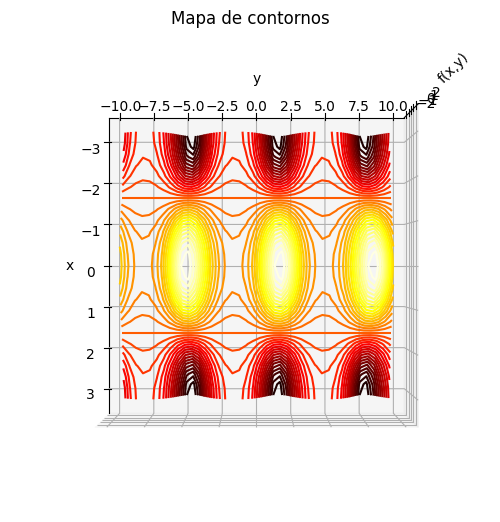

In [ ]:
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
x = np.linspace(-np.pi, np.pi, 25)
y = np.linspace(-3*np.pi, 3*np.pi, 40)
X, Y = np.meshgrid(x, y)
Z = np.cos(X)*np.exp(np.sin(Y))
ax.contour3D(X, Y, Z, 50, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Mapa de contornos')
ax.view_init(90, 0)  # Vista desde arriba
plt.show()

Se pueden crear graficas de nubes de puntos con `scatter3D`

Dame el numero de puntos a graficar: 300


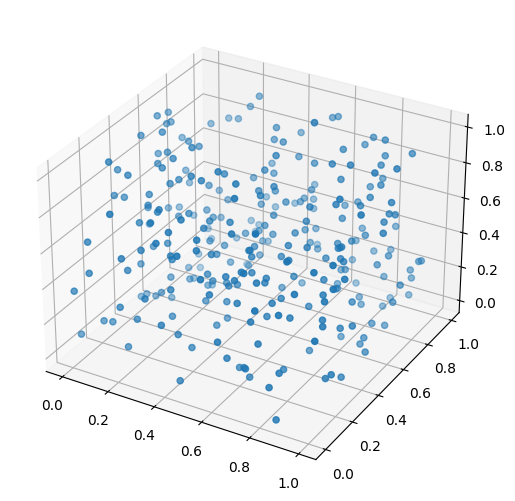

In [ ]:
puntos = int(input('Dame el numero de puntos a graficar: '))
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
x = np.random.rand(puntos)
y = np.random.rand(puntos)
z = np.random.rand(puntos)
ax.scatter3D(x, y, z)
plt.show()

O también es posible combinar varios tipos de gráficas en una sola figura aplicando varias funciones en un mismo eje. Esto se mostrará para la función de Rosenbrock $$f(x,y) = (a-x^2)^2 + b(y-x^2)^2,$$ con $a=1$ y $b=100$.

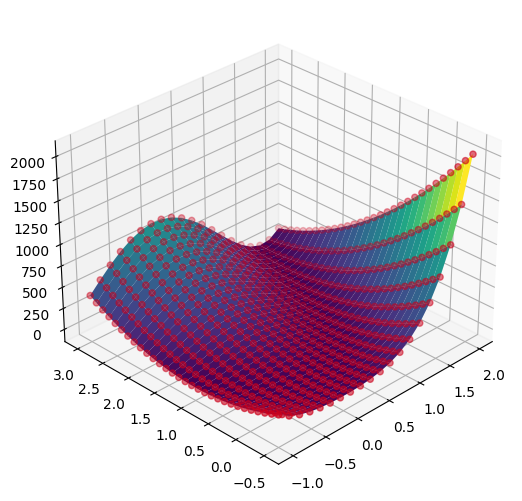

In [ ]:
a, b = 1, 100
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
x = np.linspace(-1, 2, 20)
y = np.linspace(-0.5, 3, 30)
X, Y = np.meshgrid(x, y)
Z = (a-X)**2 + b*(Y - X**2)**2
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.scatter3D(X, Y, Z, color=(0.8,0,0.1,0.7))
ax.view_init(30, -135)
plt.savefig('Rosenbrock.pdf')

Aquí para los puntos se usa la opción `color` tomando como valor una tupla con cuatro valores entre 0 y 1. Las tres primeras corresponden al color dado en RGB estandarizado (primera rojo, segunda verde y tercera azul) y una cuarta componente para el *canal alfa* (transparencia).

A veces los datos de la función se tienen en posiciones aleatorias, es decir, no vienen dados en una estructura como una malla, por ejemplo para la función de Rosenbrock se creará un conjunto de puntos aleatorios en los cuales se evaluará la función.

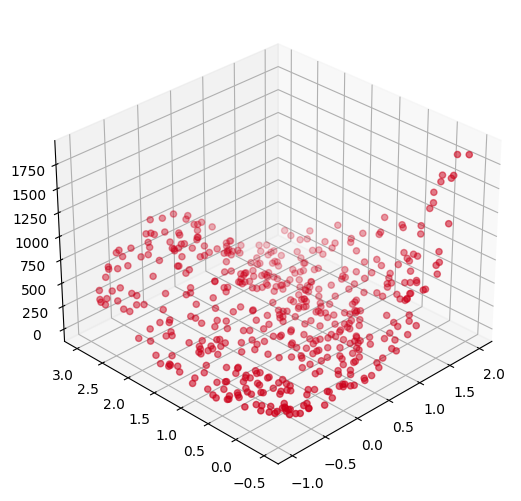

In [ ]:
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
x = 3*np.random.rand(500) - 1
y = 3.5*np.random.rand(500) - 0.5
z = (a-x)**2 + b*(y - x**2)**2
ax.scatter3D(x, y, z, color=(0.8,0,0.1,0.7))
ax.view_init(30, -135)
plt.show()

Aún con esta distribución de los puntos, es posible generar una superficie mediante `plot_trisurf`, que genera triangulaciones de los datos y las usa para generar una superficie, como la que se muestra a continuación

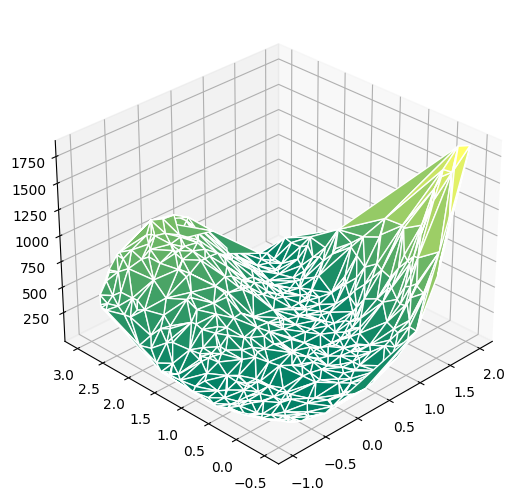

In [ ]:
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
ax.plot_trisurf(x, y, z, cmap='summer', edgecolor='white')
ax.view_init(30, -135)
plt.show()

Por último, es posible generar varias gráficas en una misma figura con la función `subplot`. Esto se muestra con el siguiente ejemplo:

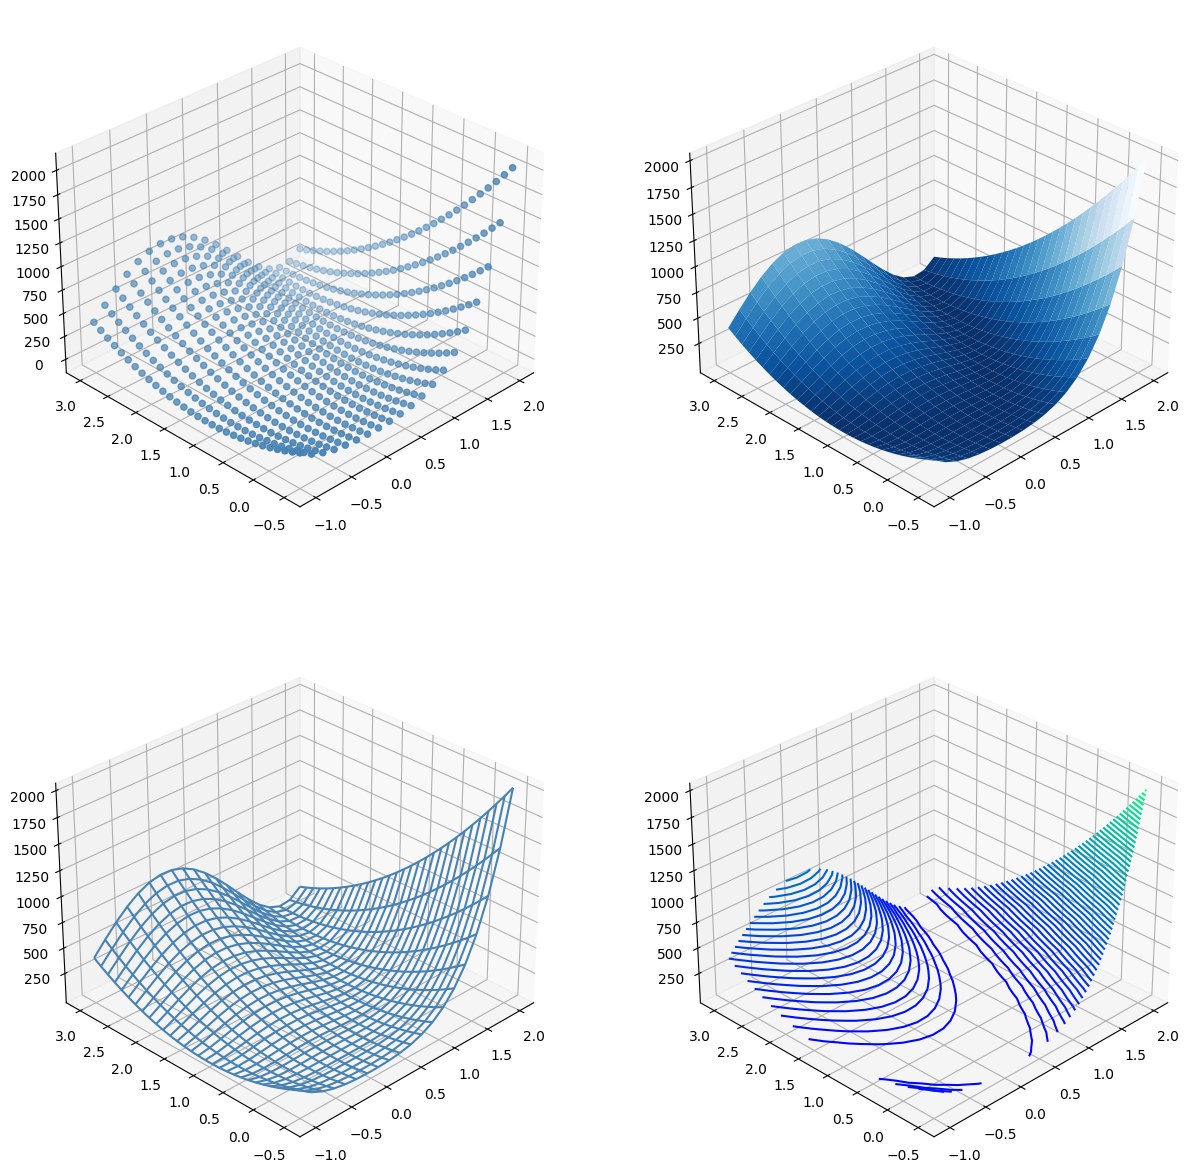

In [ ]:
fig = plt.figure(figsize=(15, 15))  # Dimensiones de la figura en pulgadas anchura y altura.

ax1 = plt.subplot(221, projection='3d')
ax1.scatter3D(X, Y, Z, color=(.275, .51, .706, 1))
ax1.view_init(30, -135)

ax2 = plt.subplot(222, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='Blues_r')
ax2.view_init(30, -135)

ax3 = plt.subplot(223, projection='3d')
ax3.plot_wireframe(X, Y, Z, color='steelblue')
ax3.view_init(30, -135)

ax4 = plt.subplot(224, projection='3d')
ax4.contour3D(X, Y, Z, 50, cmap='winter')
ax4.view_init(30, -135)

plt.show()

En este caso, para manejar las diferentes subgráficas se usa la idea de una tabla donde el primer argumento es el numero de renglones, el segundo el número de columnas y el tercero es un índice que índica la celda de la subgráfica actual. Este índice comienza en `1` que corresponde a la esquina superior izquierda y se van recorriendo de izquierda a derecha por renglones. Del ejemplo anterior, la distribución de los índices que se tiene es

$$
\begin{array}{|c|c|}\hline
    1 & 2 \\\hline
    3 & 4 \\\hline
\end{array}
$$

La distribución de las subgráficas puede ser más compleja, para más ejemplos e información revise esta [liga](https://jakevdp.github.io/PythonDataScienceHandbook/04.08-multiple-subplots.html) o la [documentación](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html) de `matplotlib`. Una manera simple de generar figuras en 3D, es usar la función `subplot` usando como primer entrada el valor `111` y el argumento ` projection='3d'`. Por ejemplo,

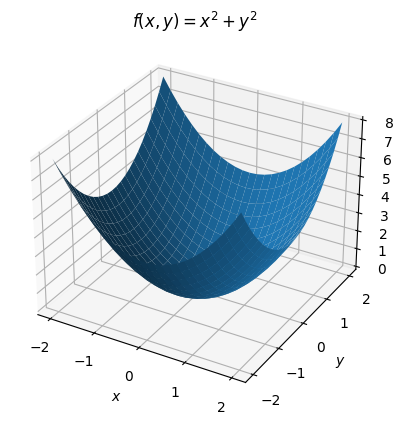

In [ ]:
ax = plt.subplot(111, projection='3d')
x = np.linspace(-2, 2, 25)
X,Y = np.meshgrid(x, x)
Z = X**2 + Y**2
ax.plot_surface(X, Y, Z)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_title('$f(x,y) = x^{2} + y^{2}$')
plt.show()

### Ejemplos

#### Ejemplo 15 (Coordenadas de una circunferencia)

En este ejemplo se definirá una función para obtener las coordenadas cartesianas de una circunferencia con radio `r` y centro `c`. Para ello usaremos la parametrización de la circunferencia, donde el parámetro será el ángulo $\alpha$, medido en radianes, entre el semieje positivo $x$ y el segmento que une el origen con el punto sobre la circunferencia, como se muestra en la siguiente figura.

<center>
<img src="https://drive.google.com/uc?id=1OmY3XiQdyeZQC0Hdzicpe1yyjeC0vBiZ" width="300" class="center">
</center>

Recordando que en un triángulo rectángulo, como el que se muestra en la figura
$$
\sin(\alpha) = \frac{\text{cateto opuesto}}{\text{hipotenusa}} = \frac{y}{h}\qquad \cos(\alpha) = \frac{\text{cateto adyacente}}{\text{hipotenusa}} = \frac{x}{h},
$$
se puede calcular las coordenadas sobre la circunferencia al despejar $x$ y $y$ de las ecuaciones anteriores. Esta definición sólo se puede usar para $0\leq\alpha\leq\pi/2$, pero como determinar $x$ y $y$ sigue siendo cierto para $0\leq\alpha\leq2\pi$. Esto se debe a las definiciones de las funciones trigonométricas seno y coseno, ya que sus valores coinciden con las coordenadas de un círculo de radio 1 centrado en el origen.

De esta manera, si $0\leq \alpha \leq 2\pi$, se tiene que $$x = r\cos(\alpha)$$ y $$y = r\sin(\alpha).$$ Si se quiere variar el centro, lo único que hay que hacer es una traslación de las coordenadas del circulo, por lo que las coordenadas para un círculo con centro $c = (c_{x},c_{y})$ están dadas por: $$x = r\cos(\alpha) + c_{x}$$ y $$y = r\sin(\alpha) + c_{y}.$$

In [ ]:
def circunferencia(c=[0, 0], r=1, p=100):
  """Calcula las coordenadas cartesianas de un circulo de radio r y centro c.

  Entrada:
    c (array): Arreglo de tamaño 2. Coordenas del centro.
    r (float): Radio.
    p (int): Numero de puntos para construir la curva.

  Salida:
    x (ndarray): Coordenadas en x de la circunferencia.
    y (ndarray): Coordenadas en y de la circunferencia.
  """
  import numpy as np
  t = np.linspace(0, 2*np.pi, p)
  x = r*np.cos(t) + c[0]
  y = r*np.sin(t) + c[1]
  return x, y

def dibujaCirc(c, r):
  """Dibuja un circulo de radio r y centro c.

  Entrada:
    c (array): Arreglo de tamaño 2. Coordenas del centro.
    r (float): Radio.
  """
  from matplotlib import pyplot as plt
  x, y = circunferencia(c, r)
  rx, ry = r*np.cos(np.pi/4) + c[0], r*np.sin(np.pi/4) + c[1]
  plt.plot(x, y, 'steelblue', [c[0], rx], [c[1], ry], '--r', c[0], c[1], 'ko')
  plt.text((c[0]+rx)/2, (c[1]+ry)/2 - r*0.1, f'r = {r:2.1f}')
  plt.text(c[0], c[1] - r*0.15, f'({c[0]:2.1f}, {c[1]:2.1f})',
           horizontalalignment='center')
  ax = plt.gca()
  ax.set_aspect(1)
  plt.show()

Dame el centro (como una lista): 2, 1.5
Dame el radio: 3.2


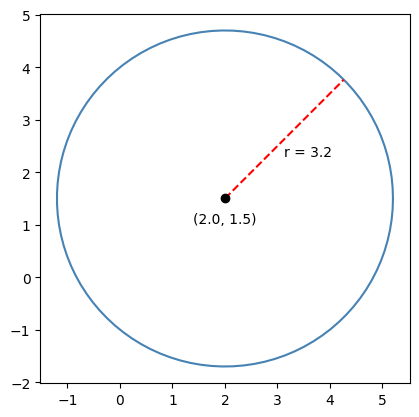

In [ ]:
c = eval(input('Dame el centro (como una lista): '))
r = float(input('Dame el radio: '))
dibujaCirc(c, r)

#### Ejemplo 16 (Árbol fractal)

Se usará las ideas de la parametrización de la circunferencia junto con la recursión para construir un árbol fractal. Aquí seguimos los siguientes pasos:

0. Definimos el numero de niveles `n` del árbol.
1. Definimos un punto inicial `p`, una longitud para el segmento `r` y un ángulo inicial `a`.
2. A partir de estos, usando la parametrización del círculo, calculamos un segundo punto `q`.
3. Dibujamos el segmento `pq`.
4. **Si `n > 0`**, cambiamos `q` por `p`, encogemos `r` mediante el factor `fr` y regresamos al punto 2 con dos nuevos ángulos `a-ang` y `a+ang` para crear la bifurcación, **de lo contrario**, terminamos.

In [ ]:
# Es necesario importar numpy para la definicion de la funcion arbol
# Descomentar si no se ha importado previamente.
#import numpy as np

def linea(xa, ya, xb, yb, color='steelblue', lw=1):
  """Dibuja el semento de recta ab.

  Entrada:
    xa (float): Coordenada x del punto a.
    ya (float): Coordenada y del punto a.
    xb (float): Coordenada x del punto b.
    yb (float): Coordenada y del punto b.
    color (str): Cadena especificando un color válido.
    lw (float): Define el ancho de la línea.
  """
  from matplotlib import pyplot as plt
  plt.plot([xa, xb], [ya, yb], color, linewidth=lw)

def arbol(p=[0, 0], r=2., a=np.pi/2., n=10, ang=np.radians(30), fr=2/3):
  """Dibuja un fractal de árbol con n niveles mediante recursión.

  Entrada:
    p (array): Arreglo de tamaño 2. Coordenadas del punto inicial.
    r (float): Longitud de los segmentos.
    a (float): Ángulo en radianes para rotar los segmentos.
    n (int): Niveles del árbol.
    ang (float): Ángulo en radianes para definir las bifurcaciones.
    fr (float): Define el factor de encogimiento de los segmentos.
  """
  # Coordenadas del punto q que forma un angulo de a grados con el punto p
  x = r*np.cos(a) + p[0]
  y = r*np.sin(a) + p[1]

  # Segmento de recta entre p y q
  c = 'forestgreen'
  if n > 5:
    c = 'darkgoldenrod'
  linea(p[0], p[1], x, y, c, max(1, n//2))

  # Bifurcacion
  if n > 0:
    arbol([x,y], fr*r, a-ang, n-1, ang, fr)
    arbol([x,y], fr*r, a+ang, n-1, ang, fr)

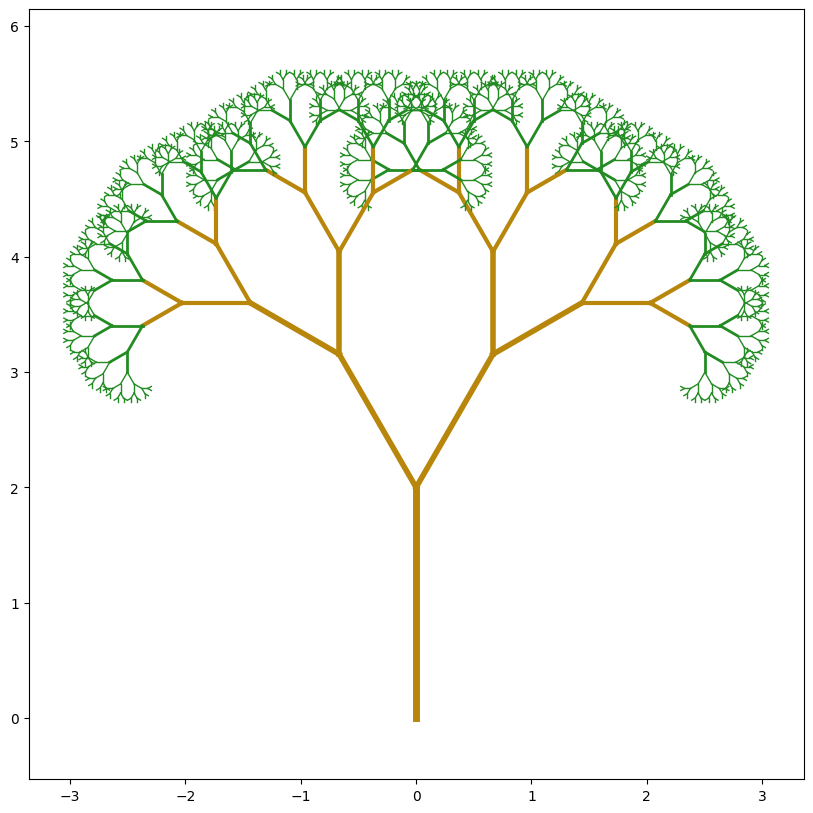

In [ ]:
fig = plt.figure(figsize=(10, 10))
arbol()
ax = plt.gca()
ax.set_aspect(1)
ax.set_adjustable('datalim')

### Paquete `tikzplotlib`

El paquete `tikzplotlib` nos permite exportar los gráficos hechos con `matplotlib` a figuras que se pueden compilar en $\LaTeX$ mediante el paquete `PGFplots`. La información completa del paquete se puede consultar en la siguiente [liga](https://pypi.org/project/tikzplotlib/).

Para poder utilizarlo dentro de Google Colab es necesario instalar el módulo usando la siguiente instrucción:

In [ ]:
!pip install tikzplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 1.3 MB/s eta 0:00:00


Para mostrar su uso se darán algunos ejemplos.

In [ ]:
# Se importa el paquete
import tikzplotlib

Dame el centro (como una lista): 2, 1.5
Dame el radio: 3.2


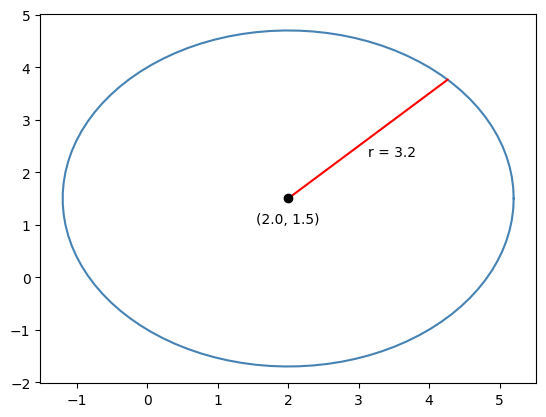

In [ ]:
# Se procede como comunmente se hace para generar gráficos con matplotlib
# y solo se cambia plt.show() por tikzplotlib.save()

c = eval(input("Dame el centro (como una lista): "))
r = float(input("Dame el radio: "))
x, y = circunferencia(c, r)
rx, ry = r*np.cos(np.pi/4) + c[0], r*np.sin(np.pi/4) + c[1]
plt.plot(x, y, 'steelblue', [c[0], rx], [c[1], ry], '-r', c[0], c[1], 'ko')
plt.text((c[0]+rx)/2, (c[1]+ry)/2 - r*0.1, f'r = {r:2.1f}')
plt.text(c[0], c[1] - r*0.15, f'({c[0]:2.1f}, {c[1]:2.1f})',
         horizontalalignment='center')
tikzplotlib.save('circulo.tex')

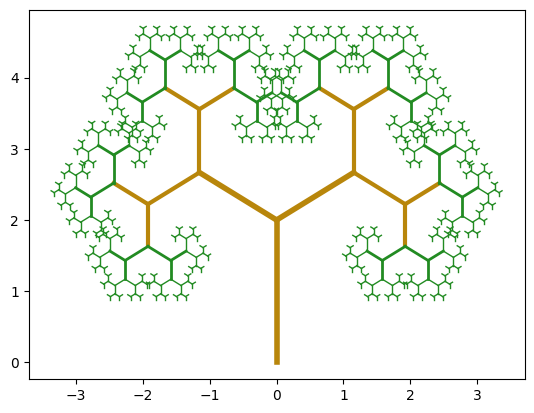

In [ ]:
arbol(n=9, ang=np.radians(60))
tikzplotlib.save('arbol.tex')